In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.datasets._samples_generator import make_blobs,make_regression
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [2]:
X_train,Y_train=make_blobs(n_samples=300,centers=2,n_features=2,cluster_std=6,random_state=42)

In [ ]:
X_train[:5],Y_train[:5]

(array([[ 6.67085728, -0.5185578 ],
        [ 8.47143359, -7.99595069],
        [-2.59018097,  2.66802055],
        [ 7.92246312,  0.76001377],
        [ 6.37852798, 14.42557448]]),
 array([1, 1, 0, 1, 1]))

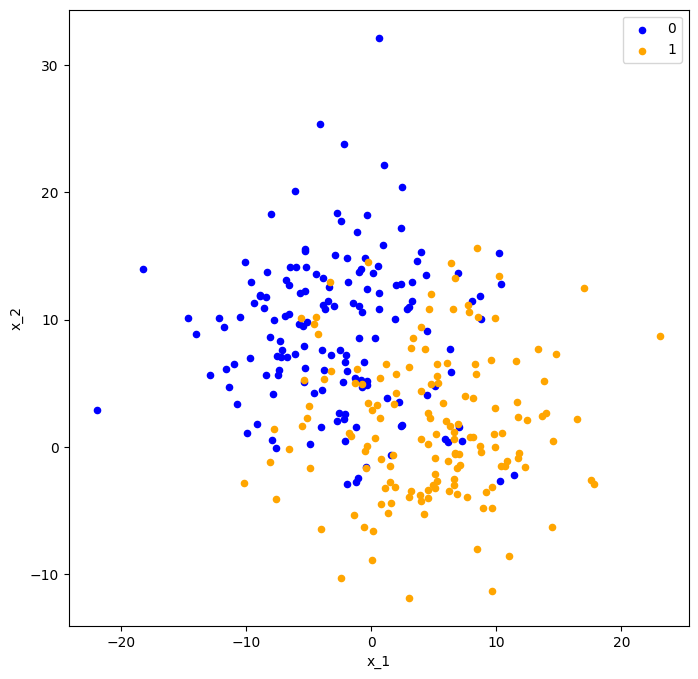

In [4]:
df=pd.DataFrame(dict(x=X_train[:,0],y=X_train[:,1],label=Y_train))
color={0:'blue',1:'orange'}
grouped=df.groupby('label')
fig,ax=plt.subplots(figsize=(8,8))
for key,group in grouped:
    group.plot(ax=ax,kind='scatter',x='x',y='y',label=key,color=color[key])
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.show()

### Feature Scaling

In [5]:
##Normalize
def normlize(X):
    x1_min=min(X_train[:,0])
    x1_max=max(X_train[:,0])
    
    f=lambda x: (x-x1_min)/(x1_max-x1_min)
    X[:,0]=f(X[:,0])

    x2_min=min(X_train[:,1])
    x2_max=max(X_train[:,1])

    f_1=lambda x:(x-x2_min)/(x2_max-x2_min)
    X[:,1]=f_1(X[:,1])

    return X

In [6]:
X=normlize(X_train)
print(X[:5],X.shape)

[[0.63518263 0.25744937]
 [0.67513332 0.08738893]
 [0.42970126 0.32992261]
 [0.66295291 0.28652828]
 [0.6286965  0.59732795]] (300, 2)


In [16]:
# find the neighbors

def find_neighbors(k,X_tr,new_point):
    neighbor_arr=[]
    for i in range(len(X_tr)):
        dist=np.sqrt(sum(np.square(X_tr[i]-new_point)))
        neighbor_arr.append([i,dist])

    neighbor_arr=sorted(neighbor_arr,key=lambda x:x[1])  #here key is use to tell which sort by which element first if it's like
    #key lambda x:(x[1],x[0]) sort by second and then first one  

    return neighbor_arr[:k]

### Classification with knn

In [22]:
def classificat(neighbor_arr):
    class_arr=[Y_train[i[0]] for i in neighbor_arr]
    #find the nearest label . i[0] takes the first valur of neighbor_arr {eg:(1,0.4)->1}
    return Counter(class_arr).most_common(1)[0][0]
    
#- Counter counts how many times each class appears among the neighbors.
#- .most_common(1) returns the most frequent class and its count.
#- [0][0] extracts just the class label (not the count).count return tuple.


In [23]:
new_points = np.array([[-10, -10],
                      [0, 10],
                      [-15, 10],
                      [5, -2]])

new_points = normlize(new_points)
new_points

array([[-10, -10],
       [  0,  10],
       [-15,  10],
       [  5,  -2]])

In [24]:
knn=find_neighbors(4,X,new_point=[1])
print(classificat(knn))

1


### Regression with knn

In [ ]:
X_,Y_=make_regression(n_samples=300,n_features=2,n_informative=2,noise=5,bias=30,random_state=42)

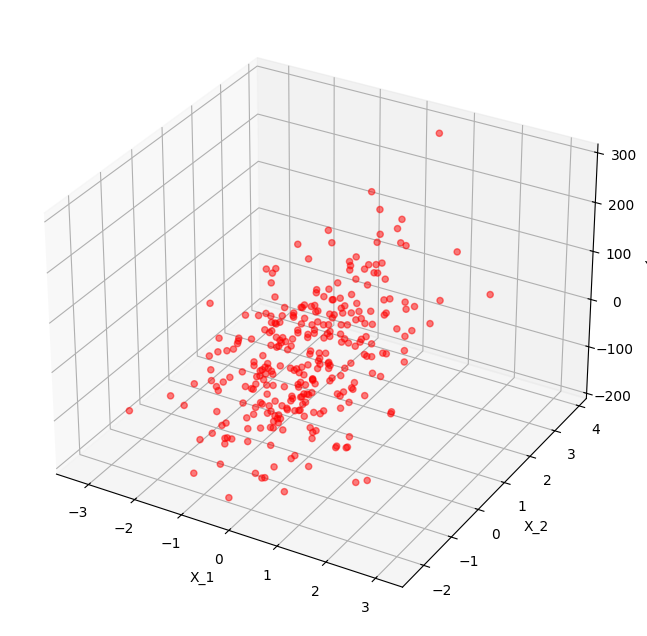

In [26]:
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_[:,0],X_[:,1],Y_,c="red",alpha=.5,marker='o')
ax.set_xlabel('X_1')
ax.set_ylabel('X_2')
ax.set_zlabel('Y')
plt.show()

In [35]:
def regressor(neighbor_arr):
    y_arr=[Y_[i[0]] for i in neighbor_arr]
    avg_y=np.mean(y_arr)
    return avg_y

In [36]:

new_po = np.array([[-1, 1],
                      [0, 2],
                      [-3, -2],
                      [3, -3]])

In [38]:
knn_=find_neighbors(3,X_,new_po[1])
print(regressor(knn_))

140.8022249608896
